In [2]:
# 图像预处理转换
transform = transforms.Compose([
    # transforms.Resize((128, 128)),  # 调整到模型输入尺寸
    transforms.Grayscale(),         # 转换为灰度图
    transforms.ToTensor(),          # 转换为张量
])


In [3]:
def load_and_preprocess_image(image_path):
    """加载并预处理单张图片"""
    image = Image.open(image_path)
    print(f"原始图片尺寸: {image.size}")
    print(f"原始图片模式: {image.mode}")
    image_tensor = transform(image).unsqueeze(0)  # 添加batch维度
    print(f"预处理后的图片尺寸: {image_tensor.shape}")
    return image_tensor


In [4]:
def visualize_feature_maps(tensor, title, num_channels=10):
    """可视化特征图"""
    tensor = tensor[0, :num_channels, :, :].detach().cpu().numpy()
    plt.figure(figsize=(12, 4))
    for i in range(num_channels):
        plt.subplot(2, 5, i + 1)
        plt.imshow(tensor[i], cmap='gray')
        plt.title(f"{title} - Ch {i+1}")
        plt.axis('off')
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

原始图片尺寸: (1280, 1024)
原始图片模式: RGB
预处理后的图片尺寸: torch.Size([1, 1, 1024, 1280])
输入图片尺寸: torch.Size([1, 1, 1024, 1280])
使用设备: cuda
[Encoder] conv1_out: torch.Size([1, 32, 1024, 1280])
[Encoder] dense_out: torch.Size([1, 128, 128, 160])
conv1_out 尺寸: torch.Size([1, 32, 1024, 1280])
dense_out 尺寸: torch.Size([1, 128, 128, 160])


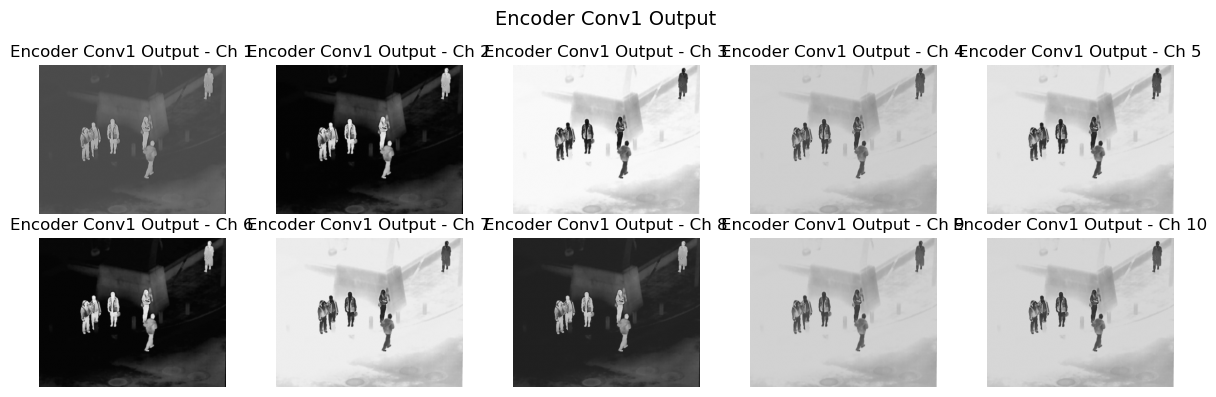

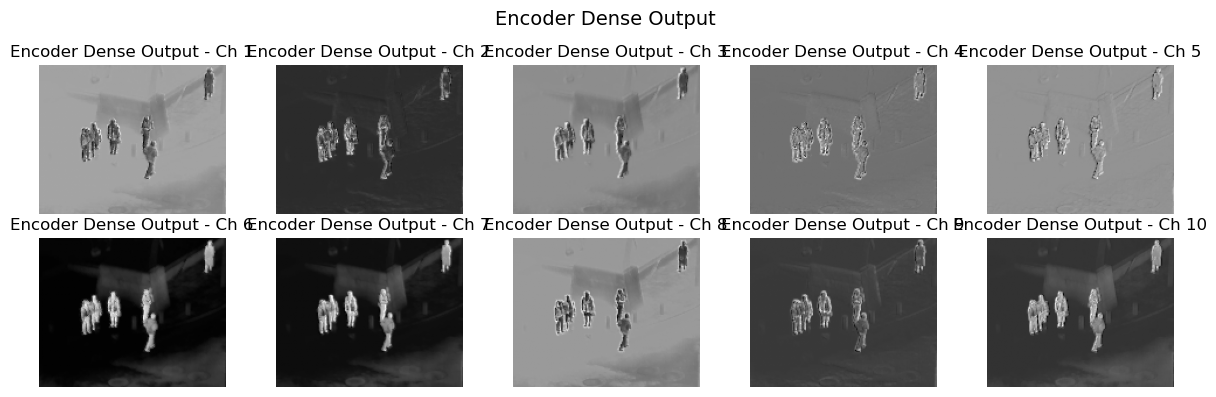

重建图像尺寸: torch.Size([1, 1, 1024, 1280])


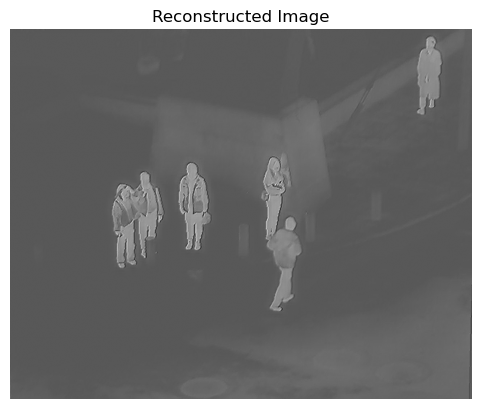

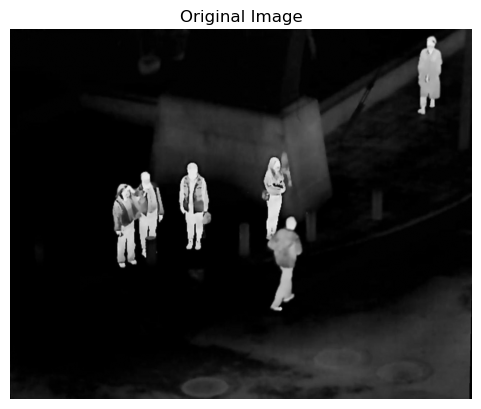

In [5]:
from network.net_autoencoder import Decoder


def test_encoder_output():
    """测试encoder输出"""
    # 1. 加载模型
    model = Encoder(in_channels=1)
    reshapModer = Decoder(in_channels=128)
    model.eval()  # 设置为评估模式
    reshapModer.eval()


    # 2. 加载图片（请替换为您的图片路径）
    # 示例：使用项目中的测试图片或指定路径
    image_path = r"../image/testNet/010001_ir.jpg"  # 请修改为实际路径
    try:
        input_tensor = load_and_preprocess_image(image_path)
        print(f"输入图片尺寸: {input_tensor.shape}")
    except FileNotFoundError:
        print(f"图片路径不存在: {image_path}")
        # 创建一个随机测试图片
        input_tensor = torch.randn(1, 1, 128, 128)
        print("使用随机测试数据")

    # GPU测试
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用设备: {device}")
    model.to(device)
    reshapModer.to(device)
    input_tensor = input_tensor.to(device)



    # 3. 前向传播
    with torch.no_grad():
        conv1_out, dense_out = model(input_tensor)
        print(f"conv1_out 尺寸: {conv1_out.shape}")
        print(f"dense_out 尺寸: {dense_out.shape}")
         # 展示conv1_out的特征图
        visualize_feature_maps(conv1_out, "Encoder Conv1 Output")
         # 展示dense_out的特征图
        visualize_feature_maps(dense_out, "Encoder Dense Output")



         # 使用decoder重建图像
        recon_img = reshapModer(conv1_out, dense_out)
        print(f"重建图像尺寸: {recon_img.shape}")
        # 可视化重建图像
        plt.imshow(recon_img[0, 0].cpu(), cmap='gray')
        plt.title("Reconstructed Image")
        plt.axis('off')
        plt.show()
        # 原图
        plt.imshow(input_tensor[0, 0].cpu(), cmap='gray')
        plt.title("Original Image")
        plt.axis('off')
        plt.show()




if __name__ == "__main__":
    test_encoder_output()